# Generative Model Evaluation
Download models · Generate synthetic tables · Study timestep impact on accuracy

## ⚙️ Configuration — edit here

In [9]:
# ── Hugging Face ──────────────────────────────────────────────────────────────
HF_REPO = "vitaliykinakh/binary-ddpm-tabular"   # <-- set your HF repo

# ── Datasets ─────────────────────────────────────────────────────────────────
# DATASETS = ["adult", "diabetes", "heloc", "housing", "sick", "travel"]
DATASETS = ["adult"]   # <-- for testing, use just one dataset

# ── Directories ───────────────────────────────────────────────────────────────
MODELS_DIR    = "./models"
OUTPUTS_DIR   = "./outputs"
EVAL_CONFIGS_DIR = "./eval_configs"
DATA_DIR      = "./data"

# ── Default sampling parameters ───────────────────────────────────────────────
DEFAULT_SAMPLE_PARAMS = dict(
    n_timesteps    = 5,
    batch_size     = 256,
    guidance_scale = 5.0,
    use_ema        = True,
)

# ── Timestep study ────────────────────────────────────────────────────────────
TIMESTEPS_TO_STUDY = [2, 5, 10]
N_RUNS_PER_STEP    = 5   # synthetic datasets generated per timestep value


## 📦 Imports

In [2]:
import os, copy, yaml
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from huggingface_hub import hf_hub_download

from sample   import sample
from evaluate import evaluate


c:\Users\Sinbad\anaconda3\envs\binary-diffusion-tabular\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## ⬇️ Download models from Hugging Face

In [3]:
def download_models(datasets, repo, models_dir):
    """Download model-final.pt and transformation.joblib for each dataset."""
    paths = {}
    for ds in datasets:
        dst = Path(models_dir) / ds
        dst.mkdir(parents=True, exist_ok=True)

        model_path = dst / "model-final.pt"
        transform_path = dst / "transformation.joblib"

        if not model_path.exists():
            print(f"[{ds}] Downloading model …")
            hf_hub_download(repo_id=repo,
                            filename=f"{ds}/model-final.pt",
                            local_dir=models_dir)
        if not transform_path.exists():
            print(f"[{ds}] Downloading transformation …")
            hf_hub_download(repo_id=repo,
                            filename=f"{ds}/transformation.joblib",
                            local_dir=models_dir)

        paths[ds] = dict(ckpt=str(model_path), ckpt_transformation=str(transform_path))
        print(f"[{ds}] ✓ ready")
    return paths

model_paths = download_models(DATASETS, HF_REPO, MODELS_DIR)


[adult] ✓ ready


## 🛠️ Helpers

In [4]:
def get_n_samples(dataset_name):
    """Count rows in the training CSV (excluding header) to match n_samples."""
    train_csv = Path(DATA_DIR) / f"{dataset_name}_train.csv"
    return sum(1 for _ in open(train_csv)) - 1   # subtract header


def get_target_column(dataset_name):
    """Read target_column from the eval config (data.target_column)."""
    cfg_path = Path(EVAL_CONFIGS_DIR) / f"{dataset_name}.yml"
    cfg = yaml.safe_load(open(cfg_path))
    return cfg["data"]["target_column"]


def build_eval_cfg(dataset_name, synthetic_paths):
    """Load the eval config and patch path_synthetic_trains."""
    cfg_path = Path(EVAL_CONFIGS_DIR) / f"{dataset_name}.yml"
    cfg = yaml.safe_load(open(cfg_path))
    cfg["path_synthetic_trains"] = [str(p) for p in synthetic_paths]
    # keep path_test pointing at the right test file
    cfg["path_test"] = str(Path(DATA_DIR) / f"{dataset_name}_test.csv")
    return cfg


## 🔄 Baseline generation
Generate **N_RUNS_PER_STEP** synthetic tables per dataset using the default timestep.

In [6]:
baseline_csv = {}   # dataset → list of CSV paths

for ds in DATASETS:
    n_samples = get_n_samples(ds)
    out_dir   = Path(OUTPUTS_DIR) / ds / "baseline"
    out_dir.mkdir(parents=True, exist_ok=True)
    csvs = []

    for run in range(N_RUNS_PER_STEP):
        out_path = out_dir / f"samples_{run}.csv"
        if out_path.exists():
            print(f"[{ds}] run {run} already exists, skipping")
        else:
            print(f"[{ds}] generating run {run} …")
            sample(
                ckpt                 = model_paths[ds]["ckpt"],
                ckpt_transformation  = model_paths[ds]["ckpt_transformation"],
                out                  = str(out_dir / f"samples_{run}.csv"),   # sample() adds .csv
                n_samples            = n_samples,
                target_column_name   = get_target_column(ds),
                **DEFAULT_SAMPLE_PARAMS,
            )
        csvs.append(out_path)

    baseline_csv[ds] = csvs
    print(f"[{ds}] ✓  {len(csvs)} files ready\n")


c:\Users\Sinbad\Documents\GitHub\computational_imaging\code\binary-diffusion-tabular\sample.py:157: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt_data = torch.load(ckpt

[adult] generating run 0 …


26112it [00:04, 5964.20it/s]                           


outputs\adult\baseline\samples_0.csv
Output path is a file. Saving to outputs\adult\baseline\samples_0.csv
Saved 26049 samples to outputs\adult\baseline\samples_0.csv
[adult] run 1 already exists, skipping
[adult] run 2 already exists, skipping
[adult] run 3 already exists, skipping
[adult] run 4 already exists, skipping
[adult] ✓  5 files ready



## 📊 Baseline evaluation

In [7]:
baseline_results = {}

for ds in DATASETS:
    cfg = build_eval_cfg(ds, baseline_csv[ds])
    res = evaluate(cfg)
    baseline_results[ds] = res
    print(f"[{ds}]  metric={res['metric']}")
    for model, scores in res["models"].items():
        print(f"  {model}: {scores['mean']:.4f} ± {scores['std']:.4f}")
    print()


  [run 1/5] outputs\adult\baseline\samples_0.csv
  [run 2/5] outputs\adult\baseline\samples_1.csv
  [run 3/5] outputs\adult\baseline\samples_2.csv
  [run 4/5] outputs\adult\baseline\samples_3.csv
  [run 5/5] outputs\adult\baseline\samples_4.csv

Dataset: ADULT | Task: classification | Metric: ACCURACY
Model           Mean         Std  All scores
------------------------------------------------------------
LR            0.8478      0.0021  [0.8510  0.8447  0.8464  0.8487  0.8478]
DT            0.8368      0.0052  [0.8438  0.8409  0.8369  0.8291  0.8334]
RF            0.8334      0.0029  [0.8363  0.8342  0.8357  0.8282  0.8325]

[adult]  metric=accuracy
  LR: 0.8478 ± 0.0021
  DT: 0.8368 ± 0.0052
  RF: 0.8334 ± 0.0029



## 🔬 Timestep study
For each dataset and each timestep value, generate `N_RUNS_PER_STEP` synthetic tables.

In [10]:
study_csv = {ds: {} for ds in DATASETS}   # dataset → timestep → [csv paths]

for ds in DATASETS:
    n_samples = get_n_samples(ds)
    params = {**DEFAULT_SAMPLE_PARAMS}       # copy so we can mutate n_timesteps

    for T in TIMESTEPS_TO_STUDY:
        out_dir = Path(OUTPUTS_DIR) / ds / f"T{T}"
        out_dir.mkdir(parents=True, exist_ok=True)
        csvs = []

        for run in range(N_RUNS_PER_STEP):
            out_path = out_dir / f"samples_{run}.csv"
            if out_path.exists():
                print(f"[{ds}|T={T}] run {run} already exists, skipping")
            else:
                print(f"[{ds}|T={T}] generating run {run} …")
                sample(
                    ckpt                = model_paths[ds]["ckpt"],
                    ckpt_transformation = model_paths[ds]["ckpt_transformation"],
                    out                 = str(out_dir / f"samples_{run}.csv"),
                    n_samples           = n_samples,
                    n_timesteps         = T,
                    batch_size          = params["batch_size"],
                    guidance_scale      = params["guidance_scale"],
                    use_ema             = params["use_ema"],
                    target_column_name  = get_target_column(ds),
                )
            csvs.append(out_path)

        study_csv[ds][T] = csvs

print("Generation complete.")


c:\Users\Sinbad\Documents\GitHub\computational_imaging\code\binary-diffusion-tabular\sample.py:157: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt_data = torch.load(ckpt

[adult|T=2] generating run 0 …


26112it [00:02, 9046.23it/s]                           
c:\Users\Sinbad\Documents\GitHub\computational_imaging\code\binary-diffusion-tabular\sample.py:157: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to 

outputs\adult\T2\samples_0.csv
Output path is a file. Saving to outputs\adult\T2\samples_0.csv
Saved 26049 samples to outputs\adult\T2\samples_0.csv
[adult|T=2] generating run 1 …


26112it [00:02, 9345.33it/s]
c:\Users\Sinbad\Documents\GitHub\computational_imaging\code\binary-diffusion-tabular\sample.py:157: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


...

outputs\adult\T10\samples_2.csv
Output path is a file. Saving to outputs\adult\T10\samples_2.csv
Saved 26049 samples to outputs\adult\T10\samples_2.csv
[adult|T=10] generating run 3 …


26112it [00:06, 3922.06it/s]
c:\Users\Sinbad\Documents\GitHub\computational_imaging\code\binary-diffusion-tabular\sample.py:157: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


outputs\adult\T10\samples_3.csv
Output path is a file. Saving to outputs\adult\T10\samples_3.csv
Saved 26049 samples to outputs\adult\T10\samples_3.csv
[adult|T=10] generating run 4 …


26112it [00:06, 3953.21it/s]


outputs\adult\T10\samples_4.csv
Output path is a file. Saving to outputs\adult\T10\samples_4.csv
Saved 26049 samples to outputs\adult\T10\samples_4.csv
Generation complete.


## 📈 Evaluate & plot

In [11]:
study_results = {ds: {} for ds in DATASETS}

for ds in DATASETS:
    for T in TIMESTEPS_TO_STUDY:
        cfg = build_eval_cfg(ds, study_csv[ds][T])
        study_results[ds][T] = evaluate(cfg)

print("Evaluation complete.")


  [run 1/5] outputs\adult\T2\samples_0.csv
  [run 2/5] outputs\adult\T2\samples_1.csv
  [run 3/5] outputs\adult\T2\samples_2.csv
  [run 4/5] outputs\adult\T2\samples_3.csv
  [run 5/5] outputs\adult\T2\samples_4.csv

Dataset: ADULT | Task: classification | Metric: ACCURACY
Model           Mean         Std  All scores
------------------------------------------------------------
LR            0.8203      0.0028  [0.8193  0.8162  0.8197  0.8216  0.8246]
DT            0.8084      0.0020  [0.8119  0.8067  0.8076  0.8065  0.8091]
RF            0.8169      0.0012  [0.8153  0.8173  0.8177  0.8159  0.8185]

  [run 1/5] outputs\adult\T5\samples_0.csv
  [run 2/5] outputs\adult\T5\samples_1.csv
  [run 3/5] outputs\adult\T5\samples_2.csv
  [run 4/5] outputs\adult\T5\samples_3.csv
  [run 5/5] outputs\adult\T5\samples_4.csv

Dataset: ADULT | Task: classification | Metric: ACCURACY
Model           Mean         Std  All scores
------------------------------------------------------------
LR            0.

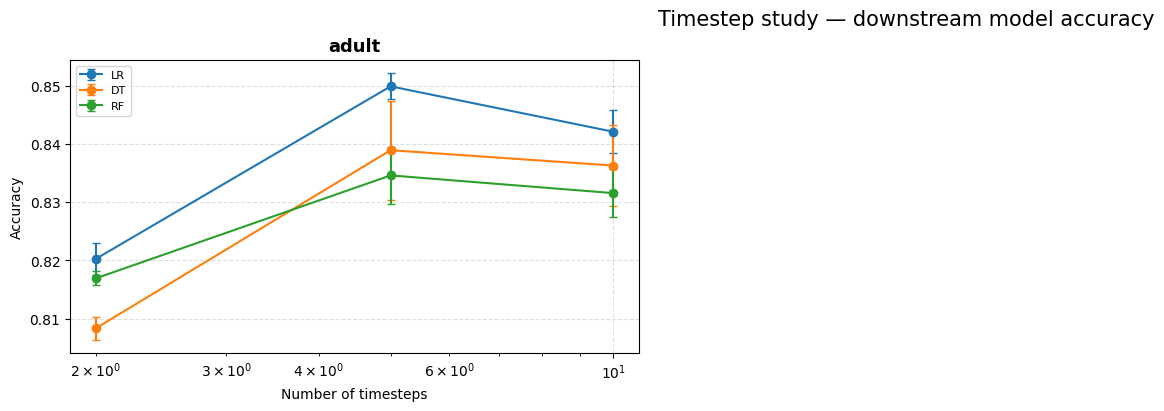

Figure saved to timestep_study.png


In [12]:
def plot_timestep_study(datasets, study_results, timesteps):
    """One subplot per dataset, one line per downstream model."""
    n = len(datasets)
    ncols = 3
    nrows = -(-n // ncols)   # ceiling division

    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows),
                             sharey=False, constrained_layout=True)
    axes = axes.flatten()

    for ax, ds in zip(axes, datasets):
        res_by_T = study_results[ds]
        # collect downstream model names from first timestep
        model_names = list(next(iter(res_by_T.values()))["models"].keys())

        for model in model_names:
            means = [res_by_T[T]["models"][model]["mean"] for T in timesteps]
            stds  = [res_by_T[T]["models"][model]["std"]  for T in timesteps]
            ax.errorbar(timesteps, means, yerr=stds, marker="o", label=model, capsize=3)

        metric = next(iter(res_by_T.values()))["metric"]
        ax.set_title(ds, fontsize=13, fontweight="bold")
        ax.set_xlabel("Number of timesteps")
        ax.set_ylabel(metric.capitalize())
        ax.set_xscale("log")
        ax.legend(fontsize=8)
        ax.grid(True, linestyle="--", alpha=0.4)

    # hide unused subplots
    for ax in axes[len(datasets):]:
        ax.set_visible(False)

    fig.suptitle("Timestep study — downstream model accuracy", fontsize=15)
    plt.savefig("timestep_study.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Figure saved to timestep_study.png")

plot_timestep_study(DATASETS, study_results, TIMESTEPS_TO_STUDY)


## 🗂️ Summary table

In [13]:
rows = []
for ds in DATASETS:
    for T in TIMESTEPS_TO_STUDY:
        res = study_results[ds][T]
        for model, scores in res["models"].items():
            rows.append(dict(
                dataset   = ds,
                timesteps = T,
                model     = model,
                mean      = round(scores["mean"], 4),
                std       = round(scores["std"],  4),
            ))

summary = pd.DataFrame(rows)
summary.to_csv("timestep_study_results.csv", index=False)
summary


,dataset,timesteps,model,mean,std
0,adult,2,LR,0.8203,0.0028
1,adult,2,DT,0.8084,0.0020
2,adult,2,RF,0.8169,0.0012
3,adult,5,LR,0.8499,0.0022
4,adult,5,DT,0.8389,0.0085
5,adult,5,RF,0.8346,0.0049
6,adult,10,LR,0.8421,0.0037
7,adult,10,DT,0.8363,0.0069
8,adult,10,RF,0.8315,0.0041
